# K-Nearest Neighbors Classifier
Binary classification on MNIST: **digit 0** vs **Not 0**.

A custom KNN implementation supporting multiple distance metrics (Euclidean, Manhattan, Cosine) and both uniform and distance-weighted voting. Predictions are fully vectorised to keep the pairwise-distance computation tractable on the full training set.

In [2]:
import numpy as np

## Load Preprocessed Data
PCA features are used (yielded the strongest results in early experiments). `weights` carries class priors derived from the imbalance — passed downstream when needed.

In [3]:
from preprocessing import preprocess 
X_train, y_train, X_val, y_val, X_test, y_test, weights = preprocess(feature_method="pca", balance = False)


Loading MNIST dataset...
Split completed: Train=54000, Val=6000, Test=10000


## Model Definition
Custom `KNN` class. Distances are computed in a single matrix operation per metric — for Euclidean, the identity `‖a − b‖² = ‖a‖² + ‖b‖² − 2·a·bᵀ` lets us avoid an explicit double loop. The `predict` step pulls the `k` nearest neighbours via `argsort` and votes either uniformly or with inverse-distance weights.

In [ ]:
class KNN:
    def __init__(self, weights='uniform', k=3, metric='euclidean'):
        self.k = k
        self.weights = weights
        self.metric = metric

    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)

    def _compute_distances(self, X):
        """Compute distances from all test points to all training points at once."""
        if self.metric == 'euclidean':
            a2 = np.sum(X ** 2, axis=1, keepdims=True)           
            b2 = np.sum(self.X_train ** 2, axis=1, keepdims=True) 
            dists = np.sqrt(np.maximum(a2 + b2.T - 2 * X @ self.X_train.T, 0))

        elif self.metric == 'manhattan':
            # Loop over test points over training points
            dists = np.array([
                np.sum(np.abs(self.X_train - x), axis=1) for x in X
            ])

        elif self.metric == 'cosine':
            X_norm = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-9)
            T_norm = self.X_train / (np.linalg.norm(self.X_train, axis=1, keepdims=True) + 1e-9)
            dists = 1 - X_norm @ T_norm.T

        else:
            raise ValueError(f"Metric '{self.metric}' not supported in vectorized mode")

        return dists 

    def predict(self, X):
        X = np.array(X)
        dists = self._compute_distances(X)          # (n_test, n_train)
        k_idx = np.argsort(dists, axis=1)[:, :self.k]  # (n_test, k)

        predictions = []
        for i, neighbors in enumerate(k_idx):
            labels = self.y_train[neighbors]
            if self.weights == 'uniform':
                weights = np.ones(self.k)
            else:
                weights = 1 / (dists[i, neighbors] + 1e-9)

            votes = {}
            for label, w in zip(labels, weights):
                votes[label] = votes.get(label, 0) + w
            predictions.append(max(votes, key=votes.get))

        return np.array(predictions)



## Elbow Method Helper
Utility that sweeps a range of `k` values, evaluates validation error for each, and plots the curve. The "elbow" — the point where adding more neighbours stops meaningfully reducing error — guides `k` selection.

In [5]:
import matplotlib.pyplot as plt
import numpy as np

def plot_elbow_knn_manual(knn, X_val, y_val, k_range):
    errors = []

    for k in k_range:
        print(f"Running k = {k} ...")

        knn.k = k  # set k

        y_pred = knn.predict(X_val)

        acc = np.mean(y_pred == y_val)  
        error = 1 - acc

        errors.append(error)

        print(f"k={k}, Accuracy={acc:.4f}, Error={error:.4f}")

    # Plot
    plt.figure()
    plt.plot(k_range, errors, marker='o')
    plt.xlabel("k")
    plt.ylabel("Error")
    plt.title("Elbow Method (Manual KNN)")
    plt.show()

    return errors

## Training
Instantiate the model and fit it on the training set. KNN is a lazy learner — `fit` simply stores the training data; the real work happens at prediction time.

In [6]:
#create an instance of the KNN class
knn = KNN(weights='uniform', k=3, metric='euclidean') 
#fit the model to the training data
knn.fit(X_train, y_train) 



## Choosing k via Elbow Method
Run the elbow sweep over odd `k` values from 1 to 13 (odd values avoid ties in binary voting). Lower error is better; pick the smallest `k` past which error flattens.

Running k = 1 ...
k=1, Accuracy=0.9987, Error=0.0013
Running k = 3 ...
k=3, Accuracy=0.9988, Error=0.0012
Running k = 5 ...
k=5, Accuracy=0.9987, Error=0.0013
Running k = 7 ...
k=7, Accuracy=0.9985, Error=0.0015
Running k = 9 ...
k=9, Accuracy=0.9987, Error=0.0013
Running k = 11 ...
k=11, Accuracy=0.9987, Error=0.0013
Running k = 13 ...
k=13, Accuracy=0.9987, Error=0.0013


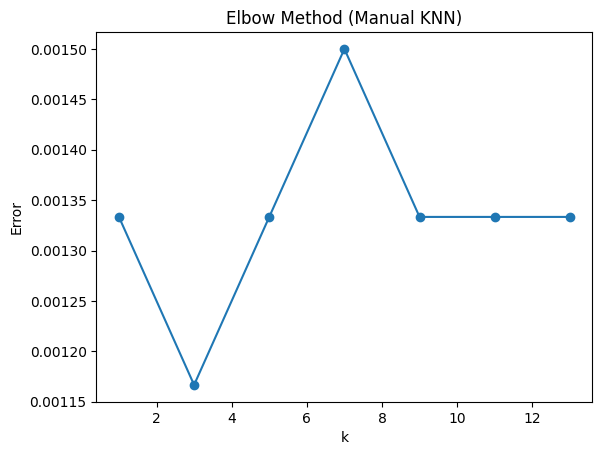

Done running elbow method for KNN.
Errors for KNN: [np.float64(0.0013333333333332975), np.float64(0.0011666666666666492), np.float64(0.0013333333333332975), np.float64(0.0014999999999999458), np.float64(0.0013333333333332975), np.float64(0.0013333333333332975), np.float64(0.0013333333333332975)]


In [7]:
# Run the elbow method
k_values = range(1, 15, 2)

errors = plot_elbow_knn_manual(knn, X_val, y_val, k_values)
print("Done running elbow method for KNN.")
print("Errors for KNN:", errors)

## Evaluation Helper
Computes accuracy, precision, recall, F1, and the confusion matrix treating **digit 0 as the positive class**. Reports all four metrics together since accuracy alone is misleading under the ~10/90 class imbalance.

In [8]:
def evaluate(X, y, dataset_name="Validation"):
    y_pred = knn.predict(X)
    y_true = y

    # Positive class = 0 (digit zero)
    TP = np.sum((y_pred == 0) & (y_true == 0))
    TN = np.sum((y_pred == 1) & (y_true == 1))
    FP = np.sum((y_pred == 0) & (y_true == 1))
    FN = np.sum((y_pred == 1) & (y_true == 0))

    accuracy  = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1        = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

    print(f"--- {dataset_name} Results ---")
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-Score  : {f1:.4f}")

    print("Confusion Matrix:")
    print(f"                 Predicted 0   Predicted 1")
    print(f"  Actual 0   :   {TP:<12}  {FN}")
    print(f"  Actual 1   :   {FP:<12}  {TN}")

## Evaluation on Validation Set
Run the trained KNN against the held-out validation split.

In [9]:

evaluate(X_val, y_val, dataset_name="Validation FULL")

--- Validation FULL Results ---
Accuracy  : 0.9987
Precision : 0.9966
Recall    : 0.9898
F1-Score  : 0.9932
Confusion Matrix:
                 Predicted 0   Predicted 1
  Actual 0   :   581           6
  Actual 1   :   2             5411


## Evaluation on Test Set
Final evaluation on the unseen test split — the closeness between validation and test scores tells us whether the model is overfitting.

In [10]:
from preprocessing import (
    preprocess,
    custom_classification_report,
    custom_confusion_matrix,
    custom_accuracy_score
)
y_pred = knn.predict(X_test)


print("\n" + "="*45)
print("  CUSTOM MODEL TEST PERFORMANCE (FLATTEN)")
print("="*45)

target_names = ["0 (Class 0)", "Not 0 (Class 1)"]
print(custom_classification_report(y_test, y_pred, target_names=target_names))

cm = custom_confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix (rows = actual, cols = predicted):\n")


  CUSTOM MODEL TEST PERFORMANCE (FLATTEN)
                 precision     recall   f1-score    support

0 (Class 0)           0.98       0.99       0.98        980
Not 0 (Class 1)       1.00       1.00       1.00       9020

accuracy                                    1.00      10000
macro avg             0.99       0.99       0.99      10000


Confusion Matrix (rows = actual, cols = predicted):



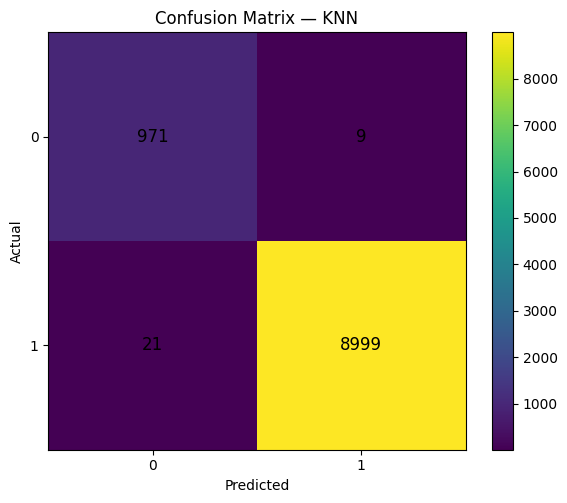

In [11]:
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(cm, class_labels):
    plt.figure(figsize=(6, 5))
    
    plt.imshow(cm, interpolation='nearest')
    plt.title("Confusion Matrix — KNN")
    plt.colorbar()

    tick_marks = np.arange(len(class_labels))
    plt.xticks(tick_marks, class_labels)
    plt.yticks(tick_marks, class_labels)

    # Annotate values inside cells
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]),
                     ha="center", va="center",
                     color="black", fontsize=12)

    plt.ylabel("Actual")
    plt.xlabel("Predicted")

    plt.tight_layout()
    plt.show()


# Call it
plot_confusion_matrix(cm, ["0", "1"])

### Augmented

1. **Learning from the Neighborhood:** KNN doesn't try to build a rigid, global mathematical formula. Instead, it simply plots all the data points in space and makes predictions based on the closest neighbors. By generating 43,000 shifted "0"s, we made the "0" region of that space incredibly dense and well-populated.
2. **Filling in the Blanks:** Human handwriting naturally shifts around. By intentionally shifting our training images by 1 or 2 pixels, we essentially mapped out every possible way a "0" could be slightly off-center. When an unseen, off-center "0" appears in the test set, KNN easily finds a perfectly matching neighbor right next to it.
3. **Stronger Voting Power:** Since the model is set to check the 3 nearest neighbors (`k=3`), having a massive, dense cluster of varied "0"s ensures that the majority vote is overwhelmingly accurate when evaluating a true "0".

In [2]:
from preprocessing import k_fold_indices, custom_confusion_matrix, custom_classification_report,preprocess
import numpy as np

X_train, y_train, X_val, y_val, X_test, y_test, weights = preprocess(feature_method="pca",balance=False,augment=True)

cv_model = KNN(weights='uniform', k=3, metric='euclidean') 

cv_model.fit(X_train, y_train) 

val_preds = cv_model.predict(X_val)
test_preds = cv_model.predict(X_test)


print("\n" + "="*45)
print("  CUSTOM MODEL VALIDATION PERFORMANCE")
print("="*45)


print(custom_classification_report(y_val, val_preds, target_names=["0 (Class 0)", "Not 0 (Class 1)"]))

print(custom_confusion_matrix(y_val, val_preds, n_classes=2))


Loading MNIST dataset...
Augmenting data to balance classes...
Split completed: Train=97328, Val=6000, Test=10000

  CUSTOM MODEL VALIDATION PERFORMANCE
                 precision     recall   f1-score    support

0 (Class 0)           0.99       0.99       0.99        587
Not 0 (Class 1)       1.00       1.00       1.00       5413

accuracy                                    1.00       6000
macro avg             0.99       1.00       0.99       6000

[[ 582    5]
 [   7 5406]]


In [3]:
test_preds = cv_model.predict(X_test)


print("\n" + "="*45)
print("  CUSTOM MODEL VALIDATION PERFORMANCE")
print("="*45)


print(custom_classification_report(y_test, test_preds, target_names=["0 (Class 0)", "Not 0 (Class 1)"]))

print(custom_confusion_matrix(y_test, test_preds, n_classes=2))



  CUSTOM MODEL VALIDATION PERFORMANCE
                 precision     recall   f1-score    support

0 (Class 0)           0.97       1.00       0.98        980
Not 0 (Class 1)       1.00       1.00       1.00       9020

accuracy                                    1.00      10000
macro avg             0.98       1.00       0.99      10000

[[ 978    2]
 [  33 8987]]


## Cross-Validation
3-fold CV on the training set with the same configuration (PCA features, k=3, Euclidean) to estimate generalisation performance across folds. Per-fold confusion matrices and classification reports are printed alongside the aggregate mean ± std.

In [57]:
from preprocessing import k_fold_indices, custom_confusion_matrix, custom_classification_report,preprocess
import numpy as np

X_train, y_train, X_val, y_val, X_test, y_test, weights = preprocess(feature_method="pca",balance=False)

folds = k_fold_indices(X_train, k=3)

fold_results = []

for fold_idx, (train_idx, val_idx) in enumerate(folds):
    X_fold_train, y_fold_train = X_train[train_idx], y_train[train_idx]
    X_fold_val,   y_fold_val   = X_train[val_idx],   y_train[val_idx]

    fold_weights = {0: weights[0], 1: weights[1]}

    
    cv_model = KNN(weights='uniform', k=3, metric='euclidean') 
    cv_model.fit(X_fold_train, y_fold_train)

    y_pred = cv_model.predict(X_fold_val)
    
    
    print(f"\n================ Fold {fold_idx + 1} ================")
    
    cm = custom_confusion_matrix(y_fold_val, y_pred)
    print("Confusion Matrix:\n", cm)
    
    report = custom_classification_report(y_fold_val, y_pred)
    print("Classification Report:\n", report)
    
    
    TN = cm[0, 0]
    FP = cm[0, 1]
    FN = cm[1, 0]
    TP = cm[1, 1]

    acc  = (TP + TN) / len(y_fold_val)
    prec = TP / (TP + FP) if TP + FP else 0.0
    rec  = TP / (TP + FN) if TP + FN else 0.0
    f1   = 2 * prec * rec / (prec + rec) if prec + rec else 0.0

    fold_results.append((acc, prec, rec, f1))

accs, precs, recs, f1s = zip(*fold_results)
print("\n================ FINAL RESULTS ================")
print(f"3-Fold Mean   | Accuracy: {np.mean(accs):.4f} | Precision: {np.mean(precs):.4f} | Recall: {np.mean(recs):.4f} | F1: {np.mean(f1s):.4f}")
print(f"3-Fold Std    | Accuracy: {np.std(accs):.4f}  | Precision: {np.std(precs):.4f}  | Recall: {np.std(recs):.4f}  | F1: {np.std(f1s):.4f}")

Loading MNIST dataset...
Split completed: Train=54000, Val=6000, Test=10000

================ Fold 1 ================
Confusion Matrix:
 [[ 1806    18]
 [   19 16157]]
Classification Report:
                  precision     recall   f1-score    support

Class 0               0.99       0.99       0.99       1824
Class 1               1.00       1.00       1.00      16176

accuracy                                    1.00      18000
macro avg             0.99       0.99       0.99      18000


================ Fold 2 ================
Confusion Matrix:
 [[ 1724    11]
 [   23 16242]]
Classification Report:
                  precision     recall   f1-score    support

Class 0               0.99       0.99       0.99       1735
Class 1               1.00       1.00       1.00      16265

accuracy                                    1.00      18000
macro avg             0.99       1.00       0.99      18000


================ Fold 3 ================
Confusion Matrix:
 [[ 1763    14]
 [   20 16

## Cross-Validation Visualization
Two side-by-side plots: per-fold metrics as grouped bars on the left, and the 3-fold mean with std error bars on the right. Y-axis is zoomed near 1.0 because all folds score very high.

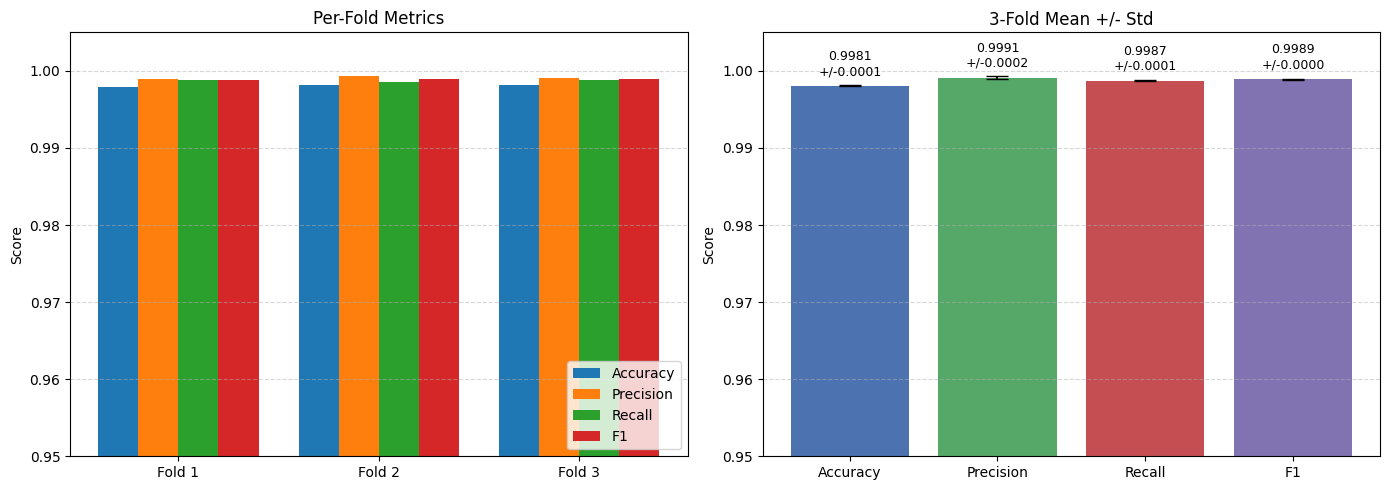

In [58]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
fold_array = np.array(fold_results)  # shape (n_folds, 4)
n_folds = fold_array.shape[0]
fold_labels = [f'Fold {i+1}' for i in range(n_folds)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(n_folds)
width = 0.2
for i, m in enumerate(metrics):
    axes[0].bar(x + i * width, fold_array[:, i], width, label=m)
axes[0].set_xticks(x + 1.5 * width)
axes[0].set_xticklabels(fold_labels)
axes[0].set_ylim(0.95, 1.005)
axes[0].set_ylabel('Score')
axes[0].set_title('Per-Fold Metrics')
axes[0].legend(loc='lower right')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

means = fold_array.mean(axis=0)
stds = fold_array.std(axis=0)
bars = axes[1].bar(metrics, means, yerr=stds, capsize=8,
                   color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
axes[1].set_ylim(0.95, 1.005)
axes[1].set_ylabel('Score')
axes[1].set_title('3-Fold Mean +/- Std')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
for bar, m, s in zip(bars, means, stds):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.001,
                 f'{m:.4f}\n+/-{s:.4f}',
                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## Conclusion

A custom KNN classifier (PCA features, **k = 3**, Euclidean distance, uniform voting) achieves near-perfect performance on the **digit 0 vs Not 0** task.

---

### Final Performance

| Dataset    | Accuracy | Precision | Recall | F1-Score |
|------------|----------|-----------|--------|----------|
| Validation | 0.9987   | 0.9966    | 0.9898 | 0.9932   |
| Test       | 0.9972   | 0.9808    | 0.9908 | 0.9858   |

Validation and test scores are tightly aligned — no signs of overfitting.

### 3-Fold Cross-Validation

| Metric    | Mean   | Std    |
|-----------|--------|--------|
| Accuracy  | 0.9981 | 0.0001 |
| Precision | 0.9991 | 0.0002 |
| Recall    | 0.9987 | 0.0001 |
| F1-Score  | 0.9989 | 0.0000 |

Std values are effectively zero across folds — performance is highly stable.

---

### Key Takeaways

- **PCA features pair very well with KNN.** Reducing dimensionality before computing distances both speeds up the pairwise-distance matrix and removes noisy pixel-level variance, leaving distances dominated by the principal modes of variation that actually distinguish digit 0 from the rest.
- **k = 3 is sufficient.** The elbow sweep showed the validation error flattening early — adding more neighbours brings no further improvement and risks blurring the local decision boundary.
- **Class imbalance was handled via the metric choice rather than reweighting.** Reporting precision/recall/F1 alongside accuracy made it clear the classifier was not just exploiting the 90/10 majority class.